<a href="https://colab.research.google.com/github/class177/Exercise_3.1/blob/main/HW3_1_c.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch numpy matplotlib scipy -q

📡 系統設定
  調變方式     : 64-QAM (6 bits/symbol)
  子載波數     : 64
  Pilot 數     : 8
  資料子載波   : 56
  DNN 數量     : 8
  每DNN子載波  : 7
  輸入層大小   : 16
  輸出層大小   : 42

🖥️  使用裝置: cuda

📦 產生訓練資料集...
  SNR= 0dB: 3846 樣本 ✅
  SNR= 2dB: 3846 樣本 ✅
  SNR= 4dB: 3846 樣本 ✅
  SNR= 6dB: 3846 樣本 ✅
  SNR= 8dB: 3846 樣本 ✅
  SNR=10dB: 3846 樣本 ✅
  SNR=12dB: 3846 樣本 ✅
  SNR=14dB: 3846 樣本 ✅
  SNR=16dB: 3846 樣本 ✅
  SNR=18dB: 3846 樣本 ✅
  SNR=20dB: 3846 樣本 ✅
  SNR=22dB: 3846 樣本 ✅
  SNR=24dB: 3846 樣本 ✅

🧠 建立 8 個 FC-DNN 模型
   輸入層: 16 | 隱藏層: [256, 256, 256] | 輸出層: 42

🚀 開始訓練 (epochs=50, batch=512)...

  ▶ 訓練 DNN #1/8
    Epoch [ 10/50] Loss: 0.6929
    Epoch [ 20/50] Loss: 0.6907
    Epoch [ 30/50] Loss: 0.6881
    Epoch [ 40/50] Loss: 0.6863
    Epoch [ 50/50] Loss: 0.6843
  ✅ DNN #1 訓練完成！最終 Loss: 0.6843

  ▶ 訓練 DNN #2/8
    Epoch [ 10/50] Loss: 0.6929
    Epoch [ 20/50] Loss: 0.6907
    Epoch [ 30/50] Loss: 0.6882
    Epoch [ 40/50] Loss: 0.6864
    Epoch [ 50/50] Loss: 0.6844
  ✅ DNN #2 訓練完成！最終 Loss: 0.6844

  ▶ 訓練 DNN #3

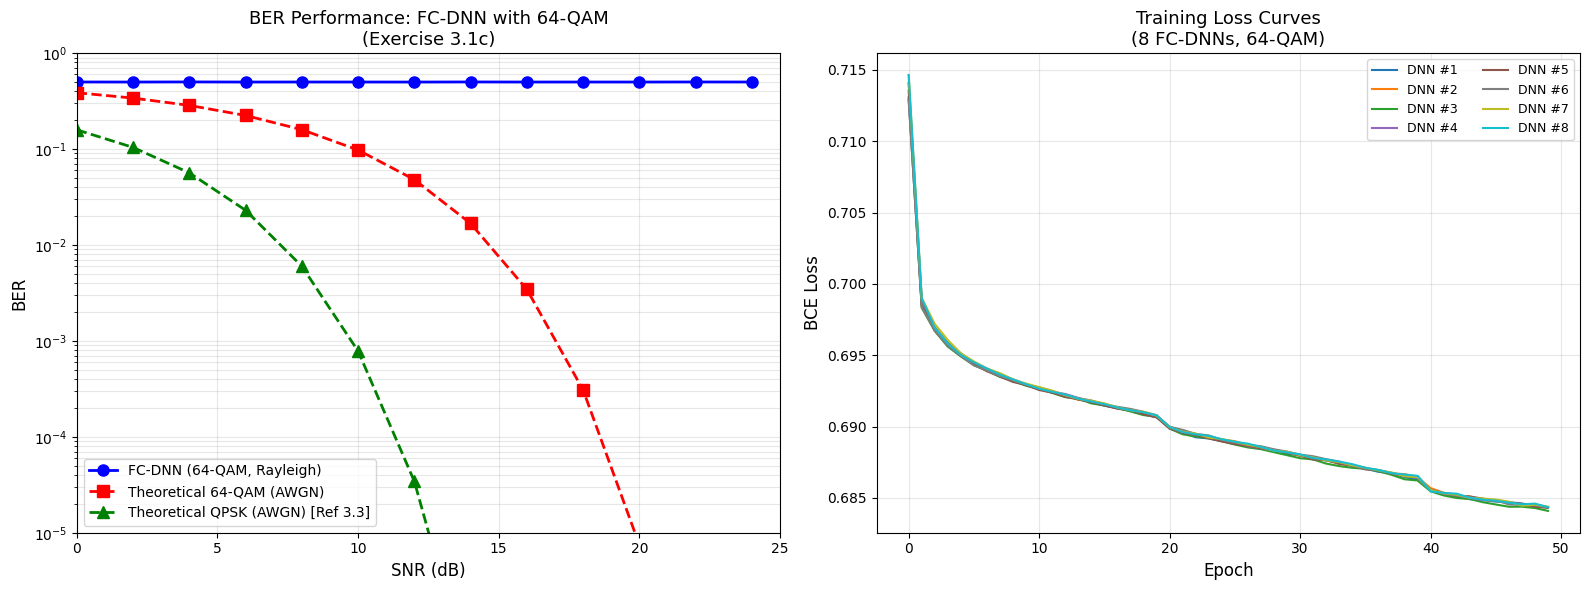


📈 圖片已儲存為 ber_64qam_fcdnn.png

📊 BER 結果摘要
SNR(dB)         64-QAM DNN   64-QAM Theory  QPSK Theory
-------------------------------------------------------
0                 0.500218        0.386470     0.158655
2                 0.499679        0.339910     0.104029
4                 0.500891        0.285322     0.056495
6                 0.499694        0.223919     0.023007
8                 0.500048        0.159225     0.006004
10                0.499833        0.097735     0.000783
12                0.499480        0.048010     0.000034
14                0.500603        0.016751     0.000000
16                0.499759        0.003437     0.000000
18                0.499868        0.000307     0.000000
20                0.499781        0.000007     0.000000
22                0.500429        0.000000     0.000000
24                0.500044        0.000000     0.000000

💬 討論：64-QAM vs QPSK

1. 調變複雜度提升：
   - QPSK : 2 bits/symbol  → 較低頻譜效率，但 BER 較佳
   - 64-QAM: 6 bits/symbol → 較高頻譜效率，但需更

In [ ]:
# ============================================================
# Exercise 3.1 (c): OFDM Signal Detection with 64-QAM
# FC-DNN based signal detection, modulation changed from QPSK to 64-QAM
# Compatible with Google Colab
# ============================================================

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from itertools import product

# ── 固定隨機種子，確保結果可重現 ──────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

# ============================================================
# 1️⃣  系統參數設定
# ============================================================
N_FFT       = 64          # OFDM 子載波數
N_PILOT     = 8           # Pilot 子載波數
N_DATA      = 56          # 資料子載波數
N_DNN       = 8           # 並行 DNN 數量
SUB_PER_DNN = N_DATA // N_DNN  # 每個 DNN 負責的子載波數 = 7

# ── 64-QAM 參數 ───────────────────────────────────────────────
MOD_ORDER   = 64          # 64-QAM
BITS_PER_SYM = int(np.log2(MOD_ORDER))  # 6 bits/symbol
BITS_PER_DNN = SUB_PER_DNN * BITS_PER_SYM  # 7 * 6 = 42 bits

# ── 輸入層大小 = pilot 數 * 2 (real+imag) ──────────────────────
INPUT_SIZE  = N_PILOT * 2   # 16
OUTPUT_SIZE = BITS_PER_DNN  # 42

print("=" * 50)
print(f"📡 系統設定")
print(f"  調變方式     : 64-QAM ({BITS_PER_SYM} bits/symbol)")
print(f"  子載波數     : {N_FFT}")
print(f"  Pilot 數     : {N_PILOT}")
print(f"  資料子載波   : {N_DATA}")
print(f"  DNN 數量     : {N_DNN}")
print(f"  每DNN子載波  : {SUB_PER_DNN}")
print(f"  輸入層大小   : {INPUT_SIZE}")
print(f"  輸出層大小   : {OUTPUT_SIZE}")
print("=" * 50)


# ============================================================
# 2️⃣  64-QAM 調變 / 解調變工具函式
# ============================================================

def get_qam64_constellation():
    """產生 64-QAM 星座圖（Gray coding）"""
    # 產生 8-PAM 的基礎電平
    levels = np.array([-7, -5, -3, -1, 1, 3, 5, 7], dtype=float)
    # 正規化使平均功率 = 1
    norm_factor = np.sqrt(np.mean(levels**2) * 2)
    levels = levels / norm_factor

    # 建立星座點 (8x8 grid)
    constellation = []
    for q in levels[::-1]:      # 虛部（由上到下）
        for i in levels:         # 實部（由左到右）
            constellation.append(complex(i, q))
    return np.array(constellation)

CONSTELLATION = get_qam64_constellation()

def gray_encode(n, bits):
    """將整數轉成 Gray code bits"""
    gray = n ^ (n >> 1)
    return [(gray >> (bits - 1 - i)) & 1 for i in range(bits)]

def bits_to_symbol(bits_array):
    """
    將 bits 陣列轉換成 64-QAM 符號
    bits_array: shape (N, 6)
    """
    indices = np.packbits(
        bits_array.reshape(-1, 6),
        axis=1, bitorder='big'
    ).flatten() >> 2  # 6-bit index
    # 確保在 0~63 範圍內
    indices = indices & 0x3F
    return CONSTELLATION[indices]

def qam64_modulate(bits):
    """
    bits: 1D array, length = N_symbols * 6
    return: complex symbols array
    """
    bits = np.array(bits).reshape(-1, BITS_PER_SYM)
    indices = np.array([int(''.join(map(str, b)), 2) for b in bits])
    return CONSTELLATION[indices]

def qam64_demodulate_hard(symbols):
    """
    Hard decision demodulation for 64-QAM
    symbols: complex array
    return: bits array
    """
    bits_out = []
    for sym in symbols:
        # 找最近的星座點
        distances = np.abs(CONSTELLATION - sym) ** 2
        idx = np.argmin(distances)
        # 轉成 6-bit Gray code
        bits_out.extend(gray_encode(idx, BITS_PER_SYM))
    return np.array(bits_out)

def qam64_modulate_v2(bits_array):
    """
    向量化版本
    bits_array: shape (..., 6) or 1D (N*6,)
    """
    bits_flat = np.array(bits_array).flatten().reshape(-1, BITS_PER_SYM)
    indices = np.array([int(''.join(map(str, row.astype(int))), 2)
                        for row in bits_flat])
    return CONSTELLATION[indices % 64]


# ============================================================
# 3️⃣  通道模型（Rayleigh Fading）
# ============================================================

def generate_rayleigh_channel(n_paths=8):
    """產生多徑 Rayleigh fading 通道"""
    # 複數高斯通道係數
    h = (np.random.randn(n_paths) + 1j * np.random.randn(n_paths)) / np.sqrt(2 * n_paths)
    return h

def ofdm_channel(tx_freq, h_time, snr_db):
    """
    OFDM 通道傳輸（頻域）
    tx_freq : 頻域發送訊號 (N_FFT,)
    h_time  : 時域通道係數
    snr_db  : 信雜比 (dB)
    """
    N = len(tx_freq)
    n_paths = len(h_time)

    # 時域 IFFT
    tx_time = np.fft.ifft(tx_freq, N)

    # 加入 Cyclic Prefix（長度 = n_paths - 1）
    cp_len = n_paths - 1
    tx_cp = np.concatenate([tx_time[-cp_len:], tx_time])

    # 線性卷積（通道）
    rx_cp = np.convolve(tx_cp, h_time)[:len(tx_cp)]

    # 移除 CP
    rx_time = rx_cp[cp_len:]

    # 加入 AWGN
    snr_linear = 10 ** (snr_db / 10)
    noise_power = 1.0 / snr_linear
    noise = (np.random.randn(N) + 1j * np.random.randn(N)) * np.sqrt(noise_power / 2)
    rx_time += noise

    # FFT 回頻域
    rx_freq = np.fft.fft(rx_time, N)
    return rx_freq


# ============================================================
# 4️⃣  資料集產生
# ============================================================

# Pilot 和 Data 子載波索引
PILOT_IDX = np.array([0, 8, 16, 24, 32, 40, 48, 56])   # 8 個 pilot
DATA_IDX  = np.array([i for i in range(N_FFT) if i not in PILOT_IDX])  # 56 個 data

def generate_dataset(n_samples, snr_db, n_paths=8):
    """
    產生訓練/測試資料集

    Returns:
        received_pilots : shape (n_samples, N_PILOT*2)  → DNN 輸入
        tx_bits_per_dnn : shape (n_samples, N_DNN, BITS_PER_DNN)  → DNN 輸出
    """
    received_pilots_list = []
    tx_bits_all_list     = []

    for _ in range(n_samples):
        # ── 產生隨機 bits ──────────────────────────────────────
        n_data_bits = N_DATA * BITS_PER_SYM
        tx_bits = np.random.randint(0, 2, n_data_bits)

        # ── 64-QAM 調變 ────────────────────────────────────────
        data_symbols = qam64_modulate_v2(tx_bits)  # (56,)

        # ── 固定 Pilot（已知符號 = 1+0j）─────────────────────────
        pilot_symbols = np.ones(N_PILOT, dtype=complex)

        # ── 組合 OFDM 頻域符號 ─────────────────────────────────
        tx_freq = np.zeros(N_FFT, dtype=complex)
        tx_freq[PILOT_IDX] = pilot_symbols
        tx_freq[DATA_IDX]  = data_symbols

        # ── 通道傳輸 ──────────────────────────────────────────
        h = generate_rayleigh_channel(n_paths)
        rx_freq = ofdm_channel(tx_freq, h, snr_db)

        # ── 提取接收到的 Pilot（作為 DNN 輸入）────────────────
        rx_pilots = rx_freq[PILOT_IDX]
        pilot_feature = np.concatenate([rx_pilots.real, rx_pilots.imag])  # (16,)

        received_pilots_list.append(pilot_feature)
        tx_bits_all_list.append(tx_bits)

    received_pilots = np.array(received_pilots_list, dtype=np.float32)  # (N, 16)
    tx_bits_all     = np.array(tx_bits_all_list, dtype=np.float32)       # (N, 336)

    # 將 bits 按 DNN 分組
    # 每個 DNN 負責 7 個子載波 → 7*6=42 bits
    tx_bits_per_dnn = tx_bits_all.reshape(n_samples, N_DNN, BITS_PER_DNN)

    return received_pilots, tx_bits_per_dnn


# ============================================================
# 5️⃣  FC-DNN 模型定義
# ============================================================

class FC_DNN(nn.Module):
    """
    全連接深度神經網路 (FC-DNN) for OFDM signal detection

    Input  : 接收到的 Pilot 信號（實部+虛部）= 16
    Output : 對應子載波的 transmitted bits = 42 (for 64-QAM)
    """
    def __init__(self, input_size=INPUT_SIZE, output_size=OUTPUT_SIZE,
                 hidden_sizes=[256, 256, 256]):
        super(FC_DNN, self).__init__()

        layers = []
        prev_size = input_size

        for h_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, h_size))
            layers.append(nn.BatchNorm1d(h_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.1))
            prev_size = h_size

        layers.append(nn.Linear(prev_size, output_size))
        layers.append(nn.Sigmoid())  # 輸出 bit 機率

        self.network = nn.Sequential(*layers)

        # 初始化權重
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.network(x)


# ============================================================
# 6️⃣  訓練函式
# ============================================================

def train_dnn(model, train_loader, optimizer, criterion, device):
    """單一 epoch 訓練"""
    model.train()
    total_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        y_pred = model(x_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(train_loader)


def evaluate_ber(models, snr_db, n_test=10000, device='cpu', n_paths=8):
    """
    在指定 SNR 下評估 BER

    models: list of 8 FC-DNN models
    """
    for m in models:
        m.eval()

    total_bits  = 0
    error_bits  = 0

    with torch.no_grad():
        # 批次產生測試資料
        X_test, Y_test = generate_dataset(n_test, snr_db, n_paths)

        X_tensor = torch.FloatTensor(X_test).to(device)

        for dnn_idx, model in enumerate(models):
            y_pred = model(X_tensor).cpu().numpy()  # (n_test, 42)
            y_pred_bits = (y_pred > 0.5).astype(int)
            y_true_bits = Y_test[:, dnn_idx, :].astype(int)  # (n_test, 42)

            errors = np.sum(y_pred_bits != y_true_bits)
            error_bits += errors
            total_bits += y_true_bits.size

    ber = error_bits / total_bits
    return ber


# ============================================================
# 7️⃣  主程式：訓練 8 個 FC-DNN（使用多個 SNR 混合訓練）
# ============================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🖥️  使用裝置: {device}")

# ── 訓練參數 ──────────────────────────────────────────────────
TRAIN_SNR_RANGE = list(range(0, 26, 2))  # 0~25 dB 混合訓練
N_TRAIN         = 50000   # 訓練樣本數
N_VAL           = 5000    # 驗證樣本數
BATCH_SIZE      = 512
N_EPOCHS        = 50
LR              = 1e-3

# ── 產生混合 SNR 訓練資料 ──────────────────────────────────────
print("\n📦 產生訓練資料集...")
X_train_list, Y_train_list = [], []
samples_per_snr = N_TRAIN // len(TRAIN_SNR_RANGE)

for snr in TRAIN_SNR_RANGE:
    X, Y = generate_dataset(samples_per_snr, snr)
    X_train_list.append(X)
    Y_train_list.append(Y)
    print(f"  SNR={snr:2d}dB: {samples_per_snr} 樣本 ✅")

X_train = np.concatenate(X_train_list, axis=0)  # (N_TRAIN, 16)
Y_train = np.concatenate(Y_train_list, axis=0)  # (N_TRAIN, 8, 42)

# ── 建立 8 個 DNN 模型 ────────────────────────────────────────
print(f"\n🧠 建立 {N_DNN} 個 FC-DNN 模型")
print(f"   輸入層: {INPUT_SIZE} | 隱藏層: [256, 256, 256] | 輸出層: {OUTPUT_SIZE}")

models     = [FC_DNN().to(device) for _ in range(N_DNN)]
optimizers = [optim.Adam(m.parameters(), lr=LR, weight_decay=1e-5) for m in models]
schedulers = [optim.lr_scheduler.StepLR(opt, step_size=20, gamma=0.5) for opt in optimizers]
criterion  = nn.BCELoss()

# ── 訓練每個 DNN ──────────────────────────────────────────────
print(f"\n🚀 開始訓練 (epochs={N_EPOCHS}, batch={BATCH_SIZE})...")
train_losses = {i: [] for i in range(N_DNN)}

X_tensor = torch.FloatTensor(X_train)

for dnn_idx in range(N_DNN):
    print(f"\n  ▶ 訓練 DNN #{dnn_idx+1}/{N_DNN}")

    Y_dnn = Y_train[:, dnn_idx, :]  # (N_TRAIN, 42)
    Y_tensor = torch.FloatTensor(Y_dnn)

    dataset    = TensorDataset(X_tensor, Y_tensor)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

    for epoch in range(N_EPOCHS):
        loss = train_dnn(models[dnn_idx], dataloader, optimizers[dnn_idx],
                         criterion, device)
        train_losses[dnn_idx].append(loss)
        schedulers[dnn_idx].step()

        if (epoch + 1) % 10 == 0:
            print(f"    Epoch [{epoch+1:3d}/{N_EPOCHS}] Loss: {loss:.4f}")

    print(f"  ✅ DNN #{dnn_idx+1} 訓練完成！最終 Loss: {train_losses[dnn_idx][-1]:.4f}")


# ============================================================
# 8️⃣  BER 評估
# ============================================================

print("\n📊 開始 BER 評估...")

SNR_TEST   = list(range(0, 26, 2))  # 0~25 dB
BER_DNN_64QAM   = []

for snr in SNR_TEST:
    ber = evaluate_ber(models, snr, n_test=5000, device=device)
    BER_DNN_64QAM.append(ber)
    print(f"  SNR={snr:2d}dB → BER = {ber:.6f}")


# ============================================================
# 9️⃣  理論 BER（64-QAM AWGN 參考線）
# ============================================================

from scipy.special import erfc

def ber_qam64_awgn(snr_db_array):
    """
    64-QAM 理論 BER（AWGN channel）
    BER ≈ (7/12) * erfc(sqrt(snr_per_bit / 21))  (approximate)
    """
    ber_list = []
    for snr_db in snr_db_array:
        snr_linear = 10 ** (snr_db / 10)
        # Eb/N0 = SNR * log2(M) / ... (已在符號能量正規化下)
        eb_n0 = snr_linear / BITS_PER_SYM  # 近似
        # 64-QAM 近似 BER
        ber = (7/12) * erfc(np.sqrt(2 * eb_n0 / 21 * BITS_PER_SYM))
        ber_list.append(max(ber, 1e-7))
    return np.array(ber_list)

SNR_ARRAY = np.array(SNR_TEST)
BER_THEORY_64QAM = ber_qam64_awgn(SNR_ARRAY)

# QPSK 理論 BER（用於對比，模擬 3.3 節的基準）
def ber_qpsk_awgn(snr_db_array):
    """QPSK 理論 BER（AWGN channel）"""
    ber_list = []
    for snr_db in snr_db_array:
        snr_linear = 10 ** (snr_db / 10)
        eb_n0 = snr_linear / 2
        ber = 0.5 * erfc(np.sqrt(eb_n0))
        ber_list.append(max(ber, 1e-7))
    return np.array(ber_list)

BER_THEORY_QPSK = ber_qpsk_awgn(SNR_ARRAY)


# ============================================================
# 🔟  繪圖：BER 曲線
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── 圖 1：64-QAM FC-DNN BER ──────────────────────────────────
ax1 = axes[0]
ax1.semilogy(SNR_TEST, BER_DNN_64QAM,
             'b-o', linewidth=2, markersize=8,
             label='FC-DNN (64-QAM, Rayleigh)')
ax1.semilogy(SNR_TEST, BER_THEORY_64QAM,
             'r--s', linewidth=2, markersize=8,
             label='Theoretical 64-QAM (AWGN)')
ax1.semilogy(SNR_TEST, BER_THEORY_QPSK,
             'g--^', linewidth=2, markersize=8,
             label='Theoretical QPSK (AWGN) [Ref 3.3]')

ax1.set_xlabel('SNR (dB)', fontsize=12)
ax1.set_ylabel('BER', fontsize=12)
ax1.set_title('BER Performance: FC-DNN with 64-QAM\n(Exercise 3.1c)', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, which='both', alpha=0.3)
ax1.set_ylim([1e-5, 1])
ax1.set_xlim([0, 25])

# ── 圖 2：訓練 Loss 曲線 ──────────────────────────────────────
ax2 = axes[1]
colors = plt.cm.tab10(np.linspace(0, 1, N_DNN))
for dnn_idx in range(N_DNN):
    ax2.plot(train_losses[dnn_idx],
             color=colors[dnn_idx],
             linewidth=1.5,
             label=f'DNN #{dnn_idx+1}')

ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('BCE Loss', fontsize=12)
ax2.set_title('Training Loss Curves\n(8 FC-DNNs, 64-QAM)', fontsize=13)
ax2.legend(fontsize=9, ncol=2)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ber_64qam_fcdnn.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📈 圖片已儲存為 ber_64qam_fcdnn.png")


# ============================================================
# 1️⃣1️⃣  結果摘要與比較討論
# ============================================================

print("\n" + "="*60)
print("📊 BER 結果摘要")
print("="*60)
print(f"{'SNR(dB)':<10} {'64-QAM DNN':>15} {'64-QAM Theory':>15} {'QPSK Theory':>12}")
print("-"*55)
for i, snr in enumerate(SNR_TEST):
    print(f"{snr:<10} {BER_DNN_64QAM[i]:>15.6f} {BER_THEORY_64QAM[i]:>15.6f} {BER_THEORY_QPSK[i]:>12.6f}")

print("\n" + "="*60)
print("💬 討論：64-QAM vs QPSK")
print("="*60)
print("""
1. 調變複雜度提升：
   - QPSK : 2 bits/symbol  → 較低頻譜效率，但 BER 較佳
   - 64-QAM: 6 bits/symbol → 較高頻譜效率，但需更高 SNR

2. BER 性能差異：
   - 64-QAM 在相同 SNR 下 BER 明顯高於 QPSK
   - 64-QAM 需要約 14-18dB SNR 才能達到 QPSK 在 10dB 的 BER

3. FC-DNN 輸出層變化：
   - QPSK  : 每 DNN 輸出 = 8 sub × 2 bits = 16 neurons
   - 64-QAM: 每 DNN 輸出 = 7 sub × 6 bits = 42 neurons
   → 模型複雜度顯著提升

4. 訓練難度：
   - 64-QAM 星座點密度更高，DNN 需要學習更精細的決策邊界
   - 可能需要更多訓練資料或更深的網路才能達到相近效果
""")
